In [1]:
!pip install h5py

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ------------------ --------------------- 1.3/2.9 MB 6.0 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 900.3 kB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 1.2 MB/s eta 0:00:00


In [6]:
!pip install matplotlib


In [76]:
!pip install tqdm

In [2]:
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
from utilities import *
x_train,y_train,x_test,y_test=load_data()    ### lecture du module utilities et appel de la fonction load_data()

In [4]:
### examination de la dimension des datas sets(train)
print(x_train.shape)
print(y_train.shape)
print(np.unique(y_train,return_counts=True))

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [5]:
### examination de la dimension des datas sets(test)
print(x_test.shape)
print(y_test.shape)
print(np.unique(y_test,return_counts=True))

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


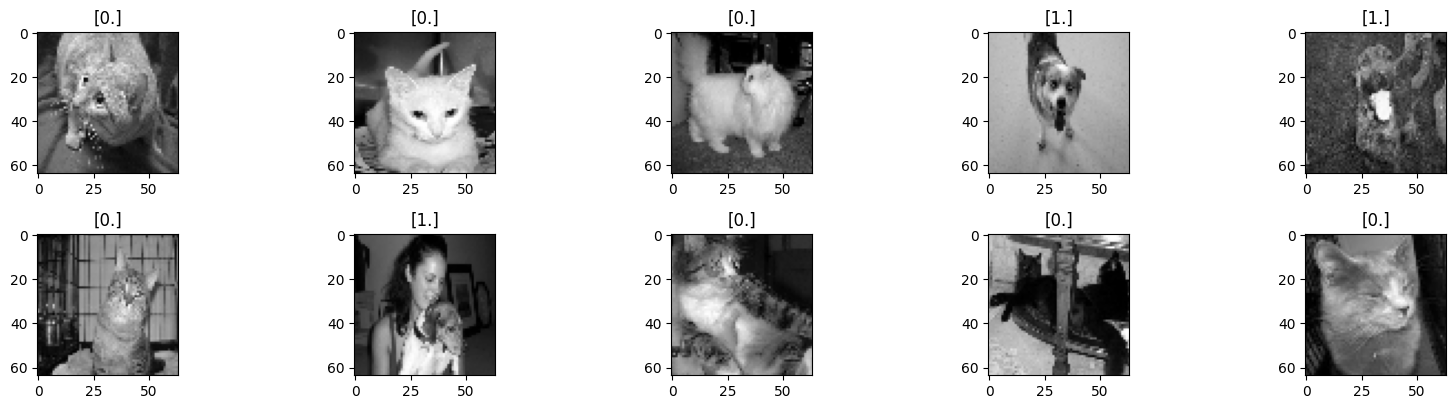

In [6]:
### ce code permet d'afficher les 10 premiere photos 
plt.figure(figsize=(16,8))

for i in range(1, 11):          # Affiche les 10 premières images
    plt.subplot(4, 5, i)        # Création du i-ème subplot dans une grille de 4 lignes × 5 colonnes
    plt.imshow(x_train[i], cmap='gray')  # Affiche l’image i en niveaux de gris
    plt.title(y_train[i])      # Ajoute un titre (la classe) à l’image
    plt.tight_layout()         # Ajuste l'espacement pour éviter que les titres se chevauchent

plt.show()                     # Affiche l’ensemble des subplots 

In [13]:
from sklearn.metrics import accuracy_score  ##pour compare les donnes

## fonction d'initialisation de nos variable

def initialisation(X):
    W=np.random.randn(X.shape[1],1)
    b=np.random.randn(1)
    return (W,b)


"""W , b= initialisation(X)
W.shape
b.shape"""
###  implementation de la fonction model  (implementation de Z et de A )

def model(X,W,b):
    Z= X.dot(W) + b    ### A.dot(B) permet de faire le produit martricielle de A et B avec numpy
    A= 1 / (1 + np.exp(-Z))   ## fonction d'activation sigmoid

    return A


"""A=model(X,W,b)
A.shape"""


### implementation de la foction cout ou LogLoss
def logloss(A,y):
    epsilon=1e-15
    return (-1/len(y))*np.sum(((y*np.log(A+epsilon))+(1-y))*np.log(1-A+epsilon))    # ici on ajoute epsilon car la valeur du contenant de log[(A) et (1-A)]peut etre negatif au null  cela permet de lever les erreurrs liees aux logarithme

"""print(logloss(A,y))"""

### implementation des fonctions de gradient

def gradients(A,X,y):
    dw=(1/len(y))*(np.transpose(X)).dot(A-y)
    db=(1/len(y))*np.sum(A-y)
    return (dw,db)


### implementation des fonction de mises  a jour 

def Update(dw,db,W,b,learning_rate):    ###learning_rate  represente alpha dans nos formulle
    W=W-learning_rate*dw
    b=b-learning_rate*db
    return (W,b)


def predict(X,W,b):
    A=model(X,W,b)
    #print(A)  
    return A >= 0.5



## rassemblement de toute ces fonction pour le neuron

def artificialNeuron(x_train,y_train,x_test,y_test,learning_rate=0.1,n_iteration=100):
    ## initialiser les parametre W et b

    W,b=initialisation(x_train)

    Loss_train=[]
    acc_train=[]

    Loss_test=[]
    acc_test=[]

    ##  creation de la boucle d'apprentissage

    for i in tqdm(range(n_iteration)):

        ## Activation
        A=model(x_train,W,b)
        A_test=model(x_test,W,b)

        if i%10==0:                ## le if permet d'ameliorer les rapidite du code 

            #TRAIN
            ## calcul du coup
            loss=logloss(A ,y_train)
            Loss_train.append(loss)
            ##Calcul de l'accuracy
            y_pred=predict(x_train,W,b)
            acc_train.append(accuracy_score(y_train,y_pred))

            ## TEST
            ## calcul du coup
            loss=logloss(A_test ,y_test)
            Loss_test.append(loss)
            ##Calcul de l'accuracy
            y_pred=predict(x_test,W,b)
            acc_test.append(accuracy_score(y_test,y_pred))


        ## mise a jour
        dw,db=gradients(A ,x_train,y_train)
        W,b=Update(dw,db,W,b,learning_rate)


    """# calcul des predictions  pour toutes les donnees x de ce dataset ie les 100 donnes
    y_pred=predict(X, W ,b)"""
    #print(accuracy_score(y_train,y_pred))
    plt.figure(figsize=(12, 4))

    # coube de perte
    plt.subplot(1, 2, 1)      ## subplot(1, 2, 1) signifie : "afficher le 1er graphe dans une grille de 1 ligne et 2 colonnes".
    plt.plot(Loss_train,label="Train Loss")   ### courbe d'apprentissage
    plt.plot(Loss_test,label="Test Loss")   ### courbe d'apprentissage
    plt.title("Courbe de perte (Loss)")
    plt.xlabel("Iterations")
    plt.ylabel("Log Loss")
    plt.legend()
    

    # coube d'exactitude
    plt.subplot(1, 2, 2)       ## subplot(1, 2, 1) signifie : "afficher le 2eme graphe dans une grille de 2 ligne et 2 colonnes".
    plt.plot(acc_train,label="Train Accuracy")   ### courbe accuracy
    plt.plot(acc_test,label="Test Accuracy")   ### courbe accuracy
    plt.title("Courbe d'exactitude (Accuracy)")
    plt.xlabel("Iterations")
    plt.ylabel("Accuracy")
    plt.legend()


    # tracage des courbe
    plt.tight_layout()
    plt.show()

    return (W,b)


In [15]:
W,b=artificialNeuron(x_train,y_train)

TypeError: artificialNeuron() missing 2 required positional arguments: 'x_test' and 'y_test'

lorsque on execute notre modele on tombe sur une erreur 'shapes (1000,1) (1000,64,1) '  car notre neuron a ete develloper pour un tableau numpy de deux dimension (X le nombre de donnes et y le nombre de variables(x1,x2,...)) .Dans ce cas nous avons 3 variables( le nombre de donnes , la taille 64*64 de chacun image) pour resoudre ce probleme et faut convertir chacun image  en ligne de 64*64=4096 pixels pour avoir un tableau numpy de deux dimensions.
on vas utiliser rechape 
x_train.shape[0]=1000 representant  la premiere dimension de notre tableau  le nombre d'elemnt 
x_train.shape[1]=64 representant  la deuxieme dimension de notre tableau  la taille horizontale
x_train.shape[2]=64 representant  la troisieme dimension de notre tableau   la taille vertical

In [16]:
x_train_reshape=x_train.reshape(x_train.shape[0],x_train.shape[1]*x_train.shape[2])
#x_train_reshape=x_train.reshape(x_train.shape[0],-1)  cette ligne est la meme avec la precedente .
"""-1 indique à NumPy de calculer automatiquement cette dimension en fonction de la taille totale du tableau et des autres dimensions données.
Autrement on redimensionne l etableau pour qu'il soit de dimension x_train.shape[0]=1000 , tout ceux qui reste a reorganiser(64*64) =4096"""
print(x_train_reshape.shape)
print(x_train_reshape.max())

(1000, 4096)
254


In [17]:
### normalisation des donnes
x_train_reshape=x_train.reshape(x_train.shape[0],x_train.shape[1]*x_train.shape[2])/x_train.max()  ### / x_train.max()  permet de normaliser les datas
print(x_train_reshape.max())

1.0


In [18]:
x_test_reshape=x_test.reshape(x_test.shape[0],-1)/x_train.max()   ### on normalise les test_data avec le Xmax du train_Data
print(x_test_reshape.shape)

(200, 4096)


  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:31<00:00, 317.45it/s]


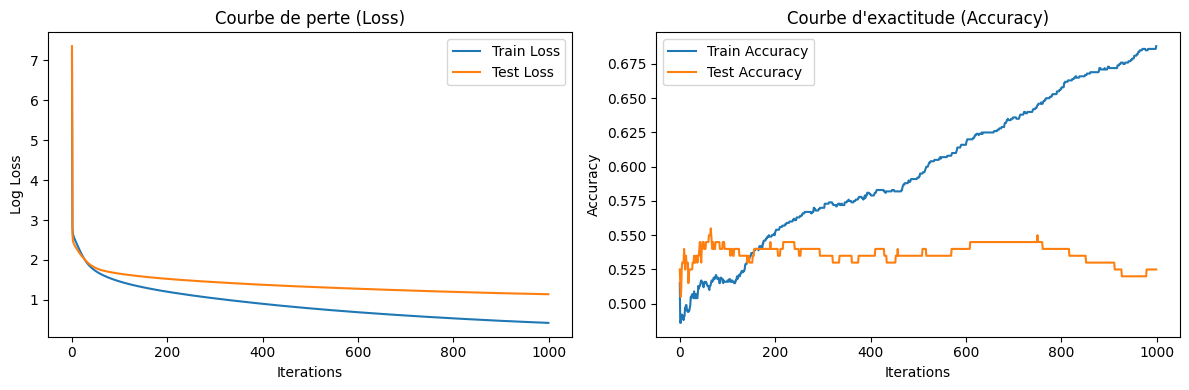

In [19]:
W,b=artificialNeuron(x_train_reshape,y_train,x_test_reshape,y_test,learning_rate=0.01,n_iteration=10000)

Prosedons a la nomalisation de nos donnes c'est a dire leurs mettre sur une meme echelle afin d'eviter que les plus grandes n'efface les plus petites
Ici on vas utiliser une formule de normalisation (X-Xmin/Xmax-Xmin)
# La courbe d'accuracy (exactitude) est très importante dans l’apprentissage automatique, car elle permet de mesurer et visualiser la performance d’un modèle au fil du temps (ou des itérations).L’accuracy (ou taux de bonne classification)
📈 Pourquoi la courbe d’accuracy est importante ?
✅ 1. Suivre l’amélioration du modèle
Elle montre si le modèle apprend bien pendant l'entraînement. Si la courbe monte progressivement, cela signifie que les prédictions deviennent de plus en plus correctes.

⚠️ 2. Détecter un surapprentissage (overfitting)
Si l’accuracy sur les données d'entraînement est très haute (par exemple 99%) mais très basse sur les données de test (par exemple 60%), alors le modèle mémorise les données au lieu de généraliser. Cela s'appelle l’overfitting.
pour resoudre le probleme de overfitting on peu fournir plus de data a notre syteme d'entrainement 
ou passe du modele de neuronne lineaire a un modele avvec plusieurs neurone

📉 3. Identifier les erreurs de modélisation
Si la courbe d’accuracy ne monte pas du tout, cela peut indiquer :

    -un problème de données,
    -un taux d’apprentissage (learning rate) mal choisi,
    -ou une mauvaise architecture du modèle.

🧠 Rôle résumé simplement :
La courbe d’accuracy sert à évaluer en temps réel si ton modèle devient meilleur ou non dans ses prédictions pendant l’entraînement.



In [ ]:
### normalisation de nos donnes 
## Xmax=255 et Xmin=0 pour chaque image de notre dataset cette application vas se faire au niveau du reshape du code precedent
## etant donne que Xmin=0 la formule de normalisation =X/Xmax